# 1. Imports, Frameworks, and Tools

In [ ]:
!pip install pandas
!pip install finvader
!pip install kagglehub
!pip install numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import os
import datetime
import time
import re
import nltk
import kagglehub
import transformers
import torch

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from finvader import finvader
from kagglehub import kagglehub

nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/c.a.charo/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/c.a.charo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/c.a.charo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/c.a.charo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/c.a.charo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/c.a.charo/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 2. Data Import

## Tweets about the Top Companies from 2015 to 2020 Dataset

## Change Directory to MyDrive
Changing the current working directory to `/content/drive/MyDrive` allows for easier file access.

In [ ]:
# Download the Tweets about the Top Companise from 2015 to 2020 Dataset
# Straight from Kaggle

path_tweetData = kagglehub.dataset_download("omermetinn/tweets-about-the-top-companies-from-2015-to-2020")

# Print out the files in the dataset & path
print(f"Files in this dataset are {os.listdir(path_tweetData)}")
print(f"Path to dataset files is {path_tweetData}")

Files in this dataset are ['Company.csv', 'Company_Tweet.csv', 'Tweet.csv']
Path to dataset files is /Users/c.a.charo/.cache/kagglehub/datasets/omermetinn/tweets-about-the-top-companies-from-2015-to-2020/versions/1


## Putting the files into dataframes

In [ ]:
company_tweets = pd.read_csv(os.path.join(path_tweetData, "Company_Tweet.csv"))
print("Comapny Tweets Dataframe:")
print(company_tweets.head())

tweets = pd.read_csv(os.path.join(path_tweetData, "Tweet.csv"))
print("Tweets Dataframe:")
print(tweets.head())

company = pd.read_csv(os.path.join(path_tweetData, "Company.csv"))
print("Company Dataframe:")
print(company.head())

Comapny Tweets Dataframe:
             tweet_id ticker_symbol
0  550803612197457920          AAPL
1  550803610825928706          AAPL
2  550803225113157632          AAPL
3  550802957370159104          AAPL
4  550802855129382912          AAPL
Tweets Dataframe:
             tweet_id           writer   post_date  \
0  550441509175443456  VisualStockRSRC  1420070457   
1  550441672312512512      KeralaGuy77  1420070496   
2  550441732014223360      DozenStocks  1420070510   
3  550442977802207232     ShowDreamCar  1420070807   
4  550443807834402816     i_Know_First  1420071005   

                                                body  comment_num  \
0  lx21 made $10,008  on $AAPL -Check it out! htt...            0   
1  Insanity of today weirdo massive selling. $aap...            0   
2  S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...            0   
3  $GM $TSLA: Volkswagen Pushes 2014 Record Recal...            0   
4  Swing Trading: Up To 8.91% Return In 14 Days h...            0   



## Values of Top NASDAQ Companies from 2010 to 2020

In [ ]:
# Import the other dataset

# Downloads the latest version
path_companyData = kagglehub.dataset_download("omermetinn/values-of-top-nasdaq-copanies-from-2010-to-2020")

# Print out the files contained in this dataset

print(f"Files in this dataset are: {os.listdir(path_companyData)}")
print(f"Path to dataset files is {path_companyData}")

Files in this dataset are: ['Company.csv', 'CompanyValues.csv']
Path to dataset files is /Users/c.a.charo/.cache/kagglehub/datasets/omermetinn/values-of-top-nasdaq-copanies-from-2010-to-2020/versions/1


## Putting these files into dataframes

In [ ]:
company_values = pd.read_csv(os.path.join(path_companyData, "CompanyValues.csv"))
print("Company Values Dataframe:")
print(company_values.head())

company_1 = pd.read_csv(os.path.join(path_companyData, "Company.csv"))
print("Company Dataframe:")
print(company_1.head())

Company Values Dataframe:
  ticker_symbol    day_date  close_value    volume  open_value  high_value  \
0          AAPL  2020-05-29       317.94  38399530      319.25      321.15   
1          AAPL  2020-05-28       318.25  33449100      316.77      323.44   
2          AAPL  2020-05-27       318.11  28236270      316.14      318.71   
3          AAPL  2020-05-26       316.73  31380450      323.50      324.24   
4          AAPL  2020-05-22       318.89  20450750      315.77      319.23   

   low_value  
0     316.47  
1     315.63  
2     313.09  
3     316.50  
4     315.35  
Company Dataframe:
  ticker_symbol company_name
0          AAPL        apple
1          GOOG   Google Inc
2         GOOGL   Google Inc
3          AMZN   Amazon.com
4          TSLA    Tesla Inc


# 3. Merging the Datasets

Below I merged 'tweets' and 'company_tweets' into one dataset called 'tweets_with_tickers' (joining them on the tweet_id's provided)

In [ ]:
tweets_with_tickers = pd.merge(tweets, company_tweets, on = 'tweet_id')
tweets_with_tickers.head()

,tweet_id,writer,post_date,body,comment_num,retweet_num,like_num,ticker_symbol
0,550441509175443456,VisualStockRSRC,1420070457,"lx21 made $10,008 on $AAPL -Check it out! htt...",0,0,1,AAPL
1,550441672312512512,KeralaGuy77,1420070496,Insanity of today weirdo massive selling. $aap...,0,0,0,AAPL
2,550441732014223360,DozenStocks,1420070510,S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...,0,0,0,AMZN
3,550442977802207232,ShowDreamCar,1420070807,$GM $TSLA: Volkswagen Pushes 2014 Record Recal...,0,0,1,TSLA
4,550443807834402816,i_Know_First,1420071005,Swing Trading: Up To 8.91% Return In 14 Days h...,0,0,1,AAPL


In [ ]:
# Before I can merge the price data to the above based on the dates I need to see if the formats are the same

print(tweets_with_tickers['post_date'].head())
print(company_values['day_date'].head())

0    1420070457
1    1420070496
2    1420070510
3    1420070807
4    1420071005
Name: post_date, dtype: int64
0    2020-05-29
1    2020-05-28
2    2020-05-27
3    2020-05-26
4    2020-05-22
Name: day_date, dtype: object


The above is obviously not the same data type so we have to convert one or the other to match.

In [ ]:
# This will covnert the Unix timestamps to datetime
tweets_with_tickers['post_date'] = pd.to_datetime(tweets_with_tickers['post_date'], unit = 's')

# And this will convert the strings used in the company_values to datetime
company_values['day_date'] = pd.to_datetime(company_values['day_date'])

# Then we check the outputs
print(tweets_with_tickers['post_date'].head())
print(company_values['day_date'].head())

0   2015-01-01 00:00:57
1   2015-01-01 00:01:36
2   2015-01-01 00:01:50
3   2015-01-01 00:06:47
4   2015-01-01 00:10:05
Name: post_date, dtype: datetime64[ns]
0   2020-05-29
1   2020-05-28
2   2020-05-27
3   2020-05-26
4   2020-05-22
Name: day_date, dtype: datetime64[ns]


In [ ]:
# In the above we can see the tweets have time values as well as dates so we will have to strip those out
tweets_with_tickers['date'] = tweets_with_tickers['post_date'].dt.date
tweets_with_tickers['date'].head()

0    2015-01-01
1    2015-01-01
2    2015-01-01
3    2015-01-01
4    2015-01-01
Name: date, dtype: object

# Removing Extraneous Columns

In [ ]:
tweets_with_tickers = tweets_with_tickers.drop(columns=['writer','comment_num', 'retweet_num', 'like_num'])
print(tweets_with_tickers.head())

             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol        date  
0  lx21 made $10,008  on $AAPL -Check it out! htt...          AAPL  2015-01-01  
1  Insanity of today weirdo massive selling. $aap...          AAPL  2015-01-01  
2  S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...          AMZN  2015-01-01  
3  $GM $TSLA: Volkswagen Pushes 2014 Record Recal...          TSLA  2015-01-01  
4  Swing Trading: Up To 8.91% Return In 14 Days h...          AAPL  2015-01-01  


## Dataset Alignment
We can see from the titles of the datasets that one covers 2010 to 2020 and the other covers 2015 to 2020. Below we verify this and trip the excess rows of the dataset that covers years not included in the other dataset

In [ ]:
# Now that we know the stock data needs to be trimmed before we merge we can take action
# Note I had to make a copy because I kept having issues later on merging the datasets and the
# dtypes not matching
company_values_trimmed = company_values[
    (company_values['day_date'] >= '2015-01-01') &
    (company_values['day_date'] <= '2019-12-31')
].copy()

# Now converting the date dtype
company_values_trimmed['day_date'] = pd.to_datetime(company_values_trimmed['day_date']).dt.date

# And then we check the results again
print(f"Earliest Data in Tweets: {tweets_with_tickers['date'].min()}")
print(f"Latest Data in Tweets: {tweets_with_tickers['date'].max()}")


Earliest Data in Tweets: 2015-01-01
Latest Data in Tweets: 2019-12-31


Glad I checked! The Twitter data actually goes to 31 December 2019, while the company value data goes to 29 May 2020. I expected the start dates not to match, but not so much the end dates.

## Final Merging of Datasets

Here we merge tweets_with_tickers and company_values, putting all of the tweets, ticker prices and dates into one unified dataset.

In [ ]:
# Merge tweets with stock prices
finished_dataset = pd.merge(
    tweets_with_tickers,
    company_values_trimmed,
    left_on=['date', 'ticker_symbol'],
    right_on=['day_date', 'ticker_symbol'],
    how='inner'
)

# Here we do a final verification that the merge worked and have a look at it
print("Merged dataset shape:", finished_dataset.shape)
print("\nFirst few rows:")
print(finished_dataset.head())
print("\nColumns:", list(finished_dataset.columns))
print(finished_dataset.info())

Merged dataset shape: (4336445, 11)

First few rows:
             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol  \
0  lx21 made $10,008  on $AAPL -Check it out! htt...          AAPL   
1  Insanity of today weirdo massive selling. $aap...          AAPL   
2  S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...          AMZN   
3  $GM $TSLA: Volkswagen Pushes 2014 Record Recal...          TSLA   
4  Swing Trading: Up To 8.91% Return In 14 Days h...          AAPL   

         date    day_date  close_value    volume  open_value  high_value  \
0  2015-01-01  2015-01-01       110.38  41304780      112.82      113.13   
1  2015-01-01  2015-01-01       110.38  41304780      112.82      113.13   
2  2015-01-01  2015-01-01  

# 4. Initial Data Visualizations

## Distribution of Tweets per Company

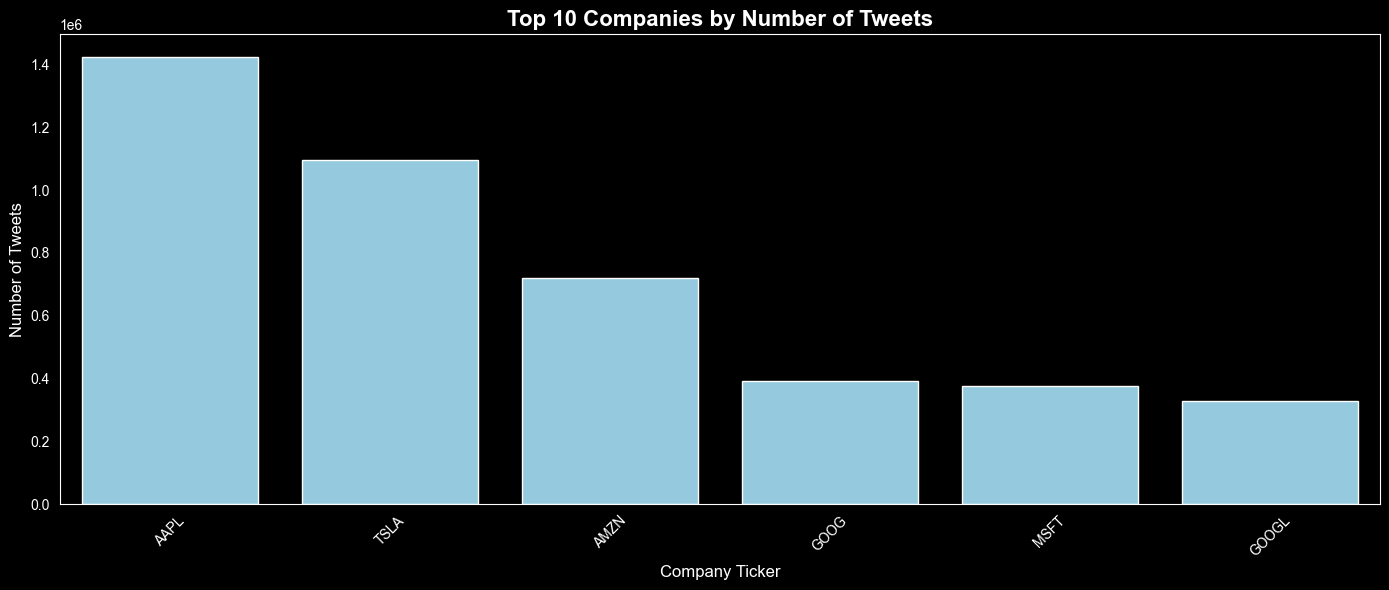

In [ ]:
sns.set_style("dark")
plt.style.use("dark_background")

plt.figure(figsize=(14, 6))
tweet_counts = finished_dataset['ticker_symbol'].value_counts().head(10)
sns.barplot(x=tweet_counts.index, y=tweet_counts.values, color='skyblue')
plt.title('Top 10 Companies by Number of Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Company Ticker', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tweet Volume Over Time

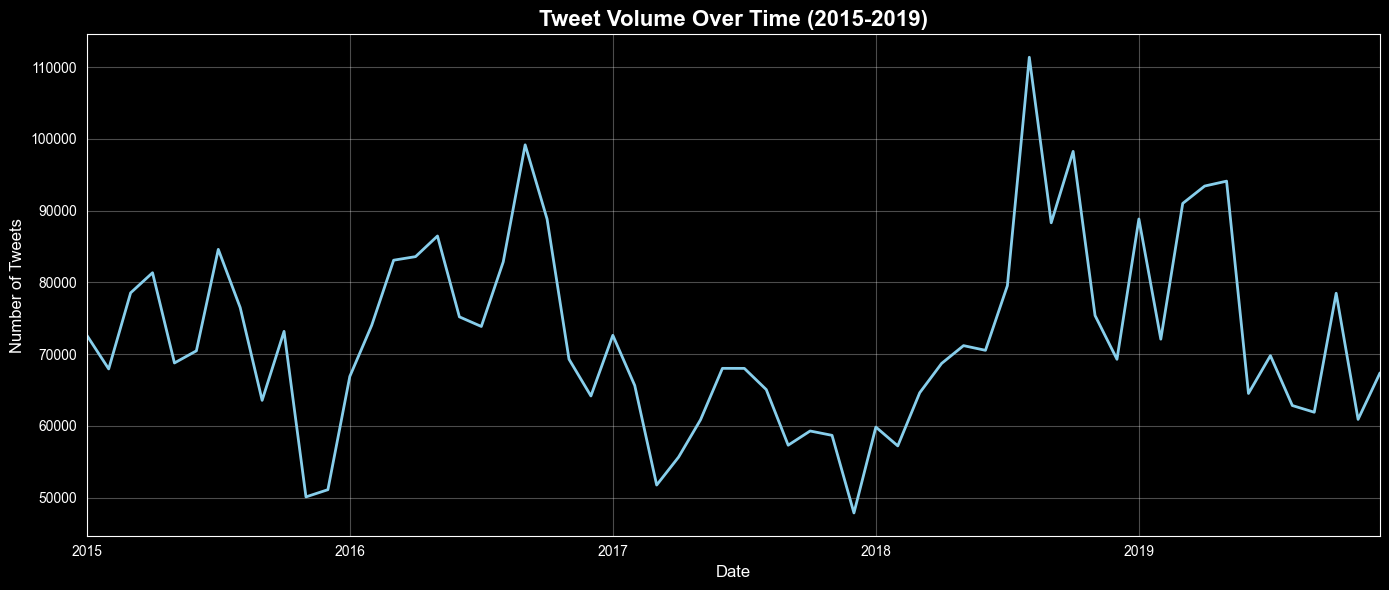

In [ ]:
sns.set_style("dark")
plt.style.use("dark_background")

plt.figure(figsize=(14, 6))
finished_dataset['date'] = pd.to_datetime(finished_dataset['date'])
tweets_per_month = finished_dataset.groupby(finished_dataset['date'].dt.to_period('M')).size()
tweets_per_month.plot(kind='line', color='skyblue', linewidth=2)
plt.title('Tweet Volume Over Time (2015-2019)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Average Closing Prices Over Time

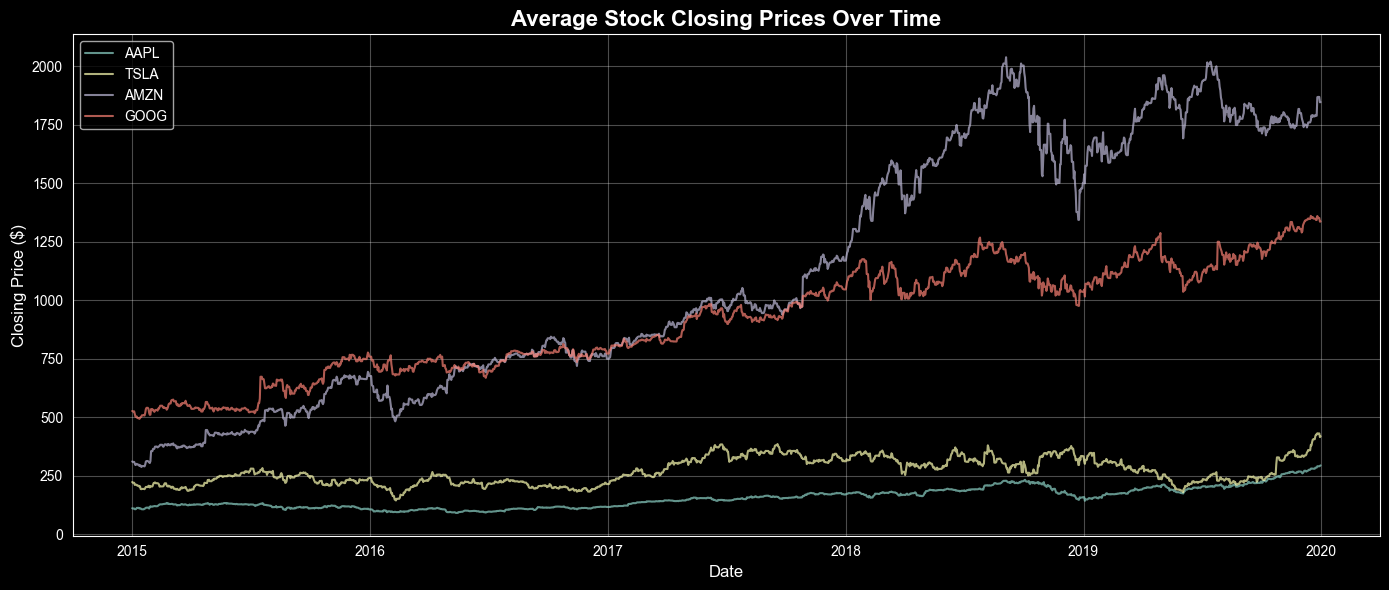

In [ ]:
sns.set_style("dark")
plt.style.use("dark_background")

plt.figure(figsize=(14, 6))
top_companies = finished_dataset['ticker_symbol'].value_counts().head(4).index # Top four to match the last visualization
for company in top_companies:
    company_data = finished_dataset[finished_dataset['ticker_symbol'] == company]
    plt.plot(company_data.groupby('date')['close_value'].mean(), label=company, alpha=0.7)
plt.title('Average Stock Closing Prices Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Avg Stock Price at Closing Over Tweet Volume

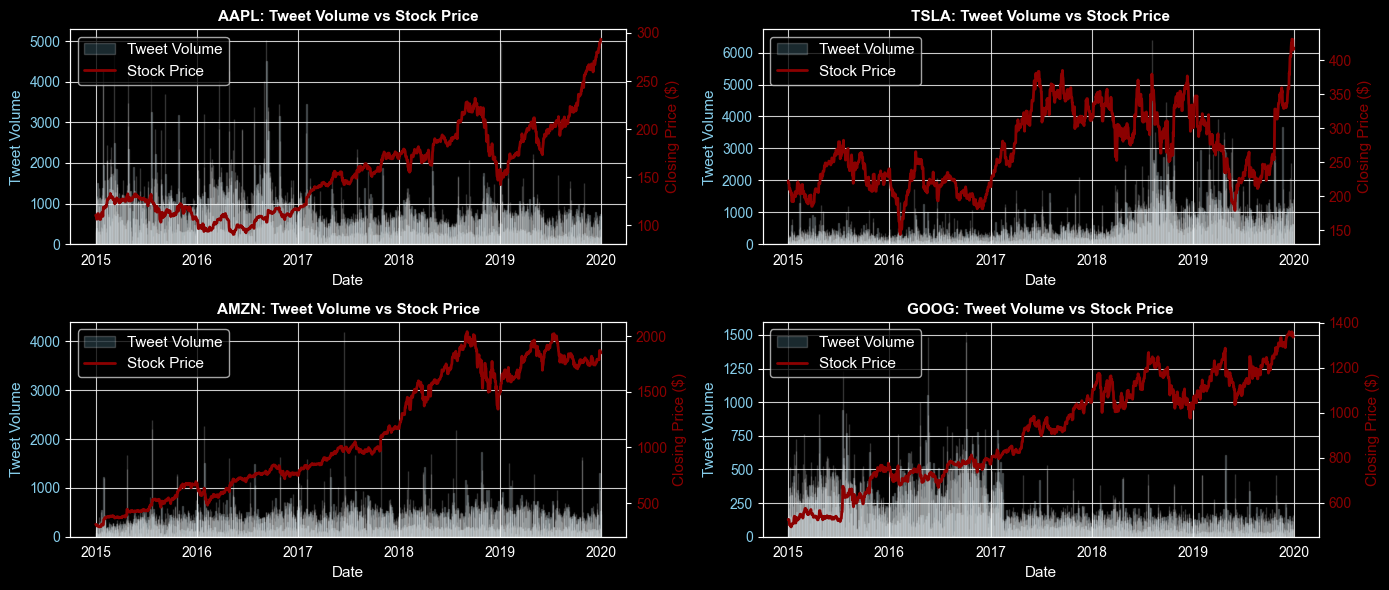

In [ ]:
# I'm looking for correlation between tweet volume and stock price swings

sns.set_style("dark")
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes = axes.flatten()

# Get top 4 companies by tweet volume
top_companies = finished_dataset['ticker_symbol'].value_counts().head(4).index

for idx, company in enumerate(top_companies):
    ax1 = axes[idx]

    # Filter the data for each company
    company_data = finished_dataset[finished_dataset['ticker_symbol'] == company].copy()

    # Group by date for tweet volume and average stock price
    daily_data = company_data.groupby('date').agg({
        'tweet_id': 'count',  # Count the tweets
        'close_value': 'mean'  # Average the closing price
    }).reset_index()

    # Create the dual axis since we are overlaying two graphs
    ax2 = ax1.twinx()

    # Plot tweet volume as bars
    ax1.bar(daily_data['date'], daily_data['tweet_id'], alpha=0.2, color='skyblue', label='Tweet Volume')
    ax1.set_ylabel('Tweet Volume', fontsize=11, color='skyblue')
    ax1.tick_params(axis='y', labelcolor='skyblue')

    # Plot stock price as line
    ax2.plot(daily_data['date'], daily_data['close_value'], color='darkred', linewidth=2, label='Stock Price')
    ax2.set_ylabel('Closing Price ($)', fontsize=11, color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')

    # Formatting
    ax1.set_xlabel('Date', fontsize=11)
    ax1.set_title(f'{company}: Tweet Volume vs Stock Price', fontsize=11, fontweight='bold')
    ax1.grid(alpha=0.8)

    # Add legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

# 6. Separate Out Samples for Manual Labeling

Before getting to the sentiment analysis and labeling using VADER, finVADER, and finBERT, our team wanted to label some data manually for comparison.

This was determined to best be done before getting into the preprocessing in preparation for the sentiment analysis.

In [ ]:
# # Set aside random unique tweets for manual labeling
# np.random.seed(25)
# manual_sample = finished_dataset.sample(n=400, random_state=25).copy()

# # Assign the datasets (2x people 200 samples each)
# manual_sample['assigned_to'] = ['TeamMate_1' if i < 200 else 'TeamMate_2' for i in range(400)]

# # Add an empty column for the manually applied labels
# manual_sample['manual_label'] = ''

# # Just a quick review to make sure it all turns out well
# print(manual_sample.head())


In [ ]:
# # Saving the set aside data to CSV so Team can add Manual Labels
# manual_sample.to_csv('ManualLabelingMaster.csv', index=False)

# 6. Pre-Processing Tweet Data for Later Sentiment Analysis

In [ ]:
print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")

Some samples from the Tweets:
1, lx21 made $10,008  on $AAPL -Check it out! http://profit.ly/1MnD8s?aff=202 Learn #howtotrade http://bit.ly/1c1NljX $EXE $WATT $IMRS $CACH $GMO

2, Insanity of today weirdo massive selling. $aapl bid up 45 cents after hours after non stop selling in trading hours

3, S&P100 #Stocks Performance $HD $LOW $SBUX $TGT $DVN $IBM $AMZN $F $APA $GM $MS $HAL $DIS $MCD $BMY $XOM  more@ http://12Stocks.com/sp100

4, $GM $TSLA: Volkswagen Pushes 2014 Record Recall Tally Higher https://pic.twitter.com/WIIc1lW7hW @ProTradersNews http://growword.com/2015/01/01/0246.html… @theferrarifan

5, Swing Trading: Up To 8.91% Return In 14 Days http://ow.ly/GDks0 #swingtrading #forecast #techstock $MWW $AAPL $TSLA



## Lowercasing the tweets

In [ ]:
def lowercase_text(text):
  return text.lower()

finished_dataset['body'] = finished_dataset['body'].apply(lowercase_text)

print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")

Some samples from the Tweets:
1, lx21 made $10,008  on $aapl -check it out! http://profit.ly/1mnd8s?aff=202 learn #howtotrade http://bit.ly/1c1nljx $exe $watt $imrs $cach $gmo

2, insanity of today weirdo massive selling. $aapl bid up 45 cents after hours after non stop selling in trading hours

3, s&p100 #stocks performance $hd $low $sbux $tgt $dvn $ibm $amzn $f $apa $gm $ms $hal $dis $mcd $bmy $xom  more@ http://12stocks.com/sp100

4, $gm $tsla: volkswagen pushes 2014 record recall tally higher https://pic.twitter.com/wiic1lw7hw @protradersnews http://growword.com/2015/01/01/0246.html… @theferrarifan

5, swing trading: up to 8.91% return in 14 days http://ow.ly/gdks0 #swingtrading #forecast #techstock $mww $aapl $tsla



## Removing URLs, mentions, hashtags and stock symbols

In [ ]:
def remove_noise(text):
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'\$[A-Z]+', '', text)
  text = re.sub(r'[^a-z\s]', '', text)
  text = ' '.join(text.split())
  return text

finished_dataset['body'] = finished_dataset['body'].apply(remove_noise)

print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")

Some samples from the Tweets:
1, lx made on aapl check it out learn howtotrade exe watt imrs cach gmo

2, insanity of today weirdo massive selling aapl bid up cents after hours after non stop selling in trading hours

3, sp stocks performance hd low sbux tgt dvn ibm amzn f apa gm ms hal dis mcd bmy xom more

4, gm tsla volkswagen pushes record recall tally higher

5, swing trading up to return in days swingtrading forecast techstock mww aapl tsla



## Tokenization

Note that this is breaking the body of each tweet into a list of words. This is necessary to remove stop words and do thie lemmatization. We will have to join the list back together later.

In [ ]:
def tokenize_text(text):
  tokens = word_tokenize(text)
  return tokens

finished_dataset['body'] = finished_dataset['body'].apply(tokenize_text)

print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")

Some samples from the Tweets:
1, ['lx', 'made', 'on', 'aapl', 'check', 'it', 'out', 'learn', 'howtotrade', 'exe', 'watt', 'imrs', 'cach', 'gmo']

2, ['insanity', 'of', 'today', 'weirdo', 'massive', 'selling', 'aapl', 'bid', 'up', 'cents', 'after', 'hours', 'after', 'non', 'stop', 'selling', 'in', 'trading', 'hours']

3, ['sp', 'stocks', 'performance', 'hd', 'low', 'sbux', 'tgt', 'dvn', 'ibm', 'amzn', 'f', 'apa', 'gm', 'ms', 'hal', 'dis', 'mcd', 'bmy', 'xom', 'more']

4, ['gm', 'tsla', 'volkswagen', 'pushes', 'record', 'recall', 'tally', 'higher']

5, ['swing', 'trading', 'up', 'to', 'return', 'in', 'days', 'swingtrading', 'forecast', 'techstock', 'mww', 'aapl', 'tsla']



## Removing the stop words

In [ ]:
stop_words = set(stopwords.words('english'))

# We need to keep the negation words so we need to exclude them from this removal
# This will help preserve negatitve sentiments

negation_words = {'no', 'not', 'never', 'neither', 'nobody', 'nothing', 'nowhere', "n't"}
stop_words = stop_words - negation_words

def remove_stopwords(tokens):
  filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
  return filtered_tokens

finished_dataset['body'] = finished_dataset['body'].apply(remove_stopwords)


print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")

Some samples from the Tweets:
1, ['made', 'aapl', 'check', 'learn', 'howtotrade', 'exe', 'watt', 'imrs', 'cach', 'gmo']

2, ['insanity', 'today', 'weirdo', 'massive', 'selling', 'aapl', 'bid', 'cents', 'hours', 'non', 'stop', 'selling', 'trading', 'hours']

3, ['stocks', 'performance', 'low', 'sbux', 'tgt', 'dvn', 'ibm', 'amzn', 'apa', 'hal', 'dis', 'mcd', 'bmy', 'xom']

4, ['tsla', 'volkswagen', 'pushes', 'record', 'recall', 'tally', 'higher']

5, ['swing', 'trading', 'return', 'days', 'swingtrading', 'forecast', 'techstock', 'mww', 'aapl', 'tsla']



## Lemmatizing

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
  lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
  return lemmatized

finished_dataset['body'] = finished_dataset['body'].apply(lemmatize_tokens)

print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/c.a.charo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Some samples from the Tweets:
1, ['made', 'aapl', 'check', 'learn', 'howtotrade', 'exe', 'watt', 'imrs', 'cach', 'gmo']

2, ['insanity', 'today', 'weirdo', 'massive', 'selling', 'aapl', 'bid', 'cent', 'hour', 'non', 'stop', 'selling', 'trading', 'hour']

3, ['stock', 'performance', 'low', 'sbux', 'tgt', 'dvn', 'ibm', 'amzn', 'apa', 'hal', 'dis', 'mcd', 'bmy', 'xom']

4, ['tsla', 'volkswagen', 'push', 'record', 'recall', 'tally', 'higher']

5, ['swing', 'trading', 'return', 'day', 'swingtrading', 'forecast', 'techstock', 'mww', 'aapl', 'tsla']



In [ ]:
# Joining the words back together

finished_dataset['body'] = finished_dataset['body'].apply(lambda x: ' '.join(x))

## Dataset Checkpoint #1 - After pre-processing / Before Labeling

In [ ]:
# Saving the dataset to a pickle file
save_path = '/content/drive/MyDrive/Colab Notebooks/finished_dataset_Before_Labeling.pkl'

finished_dataset.to_pickle(save_path)

             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  41304780      112.82      113.13     110.21   
1  2015-01-01       110.38  41304780      112.82      113.13     110.21   
2  2015-01-01    

In [ ]:
# Loading the dataset (after NLP processing, but before training and further feature engineering).
# This is so we can rerun the viz code for the labeling below

# Loading the data back in
load_path = '/Users/c.a.charo/Desktop/DataScienceCapstone/finished_dataset_after_Fully_Labeled.pkl'
finished_dataset = pd.read_pickle(load_path)

print(finished_dataset.head())

             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  41304780      112.82      113.13     110.21   
1  2015-01-01       110.38  41304780      112.82      113.13     110.21   
2  2015-01-01    

# 6. Three different ways to label a tweet as Positive/Negative/Neutral

It is understood that our original data set containing tweets did not have labels. Being that there are over 4.3 million records this poses some trouble.

This brought our group's conversation to an interesting point. We used VADER last week to produce labels. Then it was brough up in discussion that we could use FinVADER (VADER specifically tuned to financial sentiment). We are going to do this as well. And then we discovred finBERT which we also used. finBERT was arrived at in a pinch and is highly regarded for its accuracy and domain specific tuning.

400 random samples were pulled out for manual labeling by the team to compare how the models used stack up and to help in selecting the best label set (most accurate) before moving on to the stock price change prediction portion of the project.


## VADER

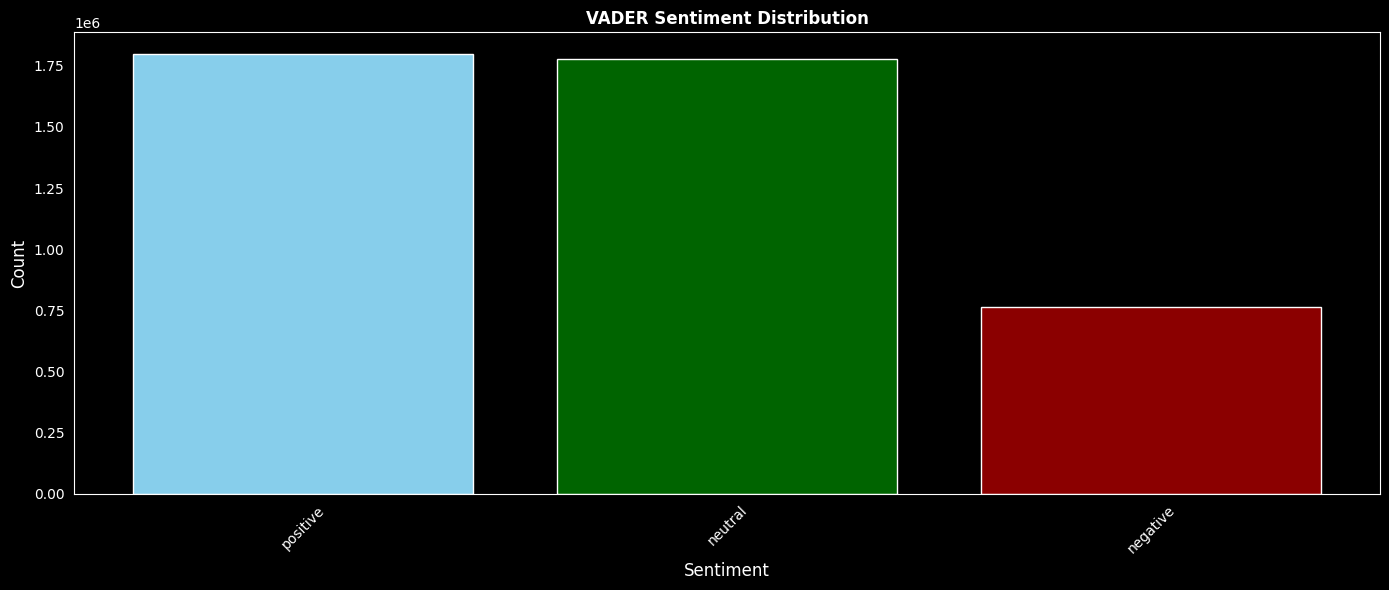

In [ ]:
vader = SentimentIntensityAnalyzer()

def vader_sentiment(text):
  scores = vader.polarity_scores(text)
  compound = scores['compound']

  if compound >= 0.05:
    return 'positive'
  elif compound <= -0.05:
    return 'negative'
  else:
    return 'neutral'

finished_dataset['vader_sentiment'] = finished_dataset['body'].apply(vader_sentiment)

print("Some samples from the Tweets:")
for i in range(5):
  print(f"{i+1}, {finished_dataset['body'].iloc[i]}\n")
print("\nSentiment distribution:")
print(finished_dataset['vader_sentiment'].value_counts())

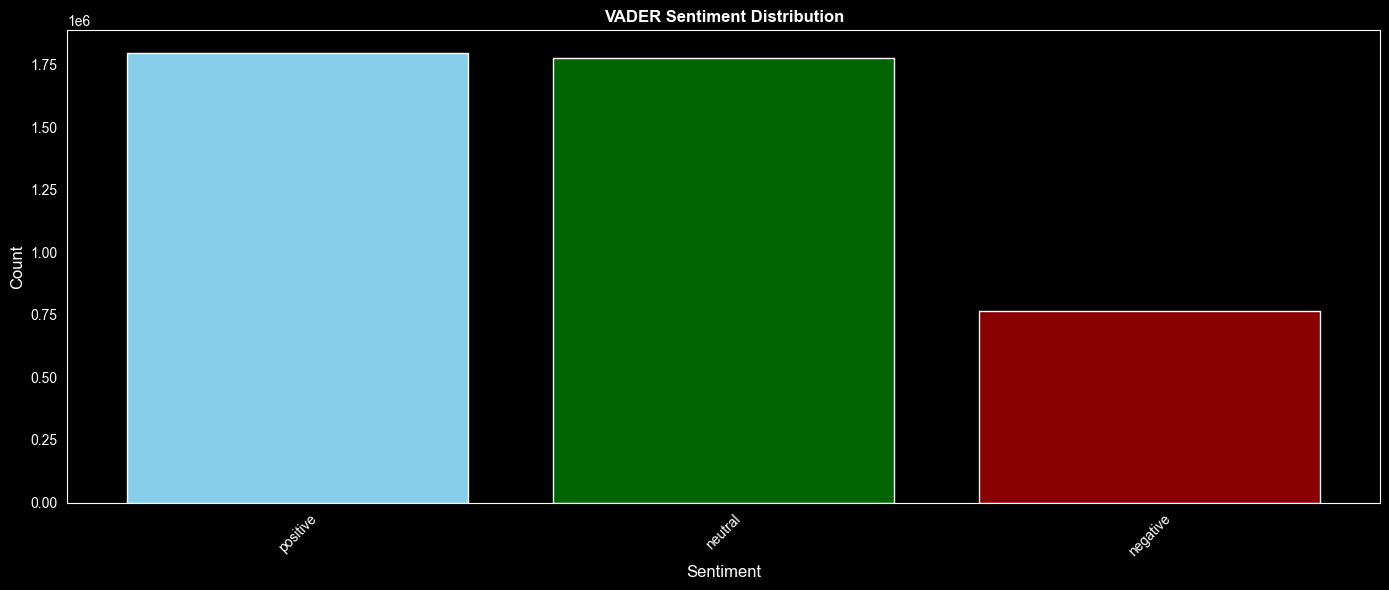

In [ ]:
# Quick visual for the VADER results. I'll do this for the finVADER results aslo
# then i'll do one side by side to see how they stacked up

sns.set_style("dark")
plt.style.use("dark_background")

plt.figure(figsize=(14, 6))
sentiment_counts = finished_dataset['vader_sentiment'].value_counts()
colors = ['skyblue', 'darkgreen', 'darkred']

plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title('VADER Sentiment Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Dataset Checkpoint #2 - After VADER Labeling

In [ ]:
# Setting the path to save the pickle file to
save_path = '/Users/c.a.charo/Desktop/DataScienceCapstone/finished_dataset_after_VADER.pkl'

finished_dataset.to_pickle(save_path)

Dataset successfully loaded from /content/drive/MyDrive/Data Science Capstone/IDC 6190 - Capstone/Data/finished_dataset_after_VADER.pkl
             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  413

In [ ]:
# Loading the dataset (after NLP processing, but before training and further feature engineering).
# This is so we can rerun the viz code for the labeling below

# Loading the data back in
load_path = '/Users/c.a.charo/Desktop/DataScienceCapstone/finished_dataset_after_VADER.pkl'
finished_dataset = pd.read_pickle(load_path)

print(finished_dataset.head())

## finVADER Labeling

In [ ]:
from tqdm import tqdm
tqdm.pandas()

def get_finvader_sentiment(text):
  scores = finvader(text, use_sentibignomics=True, use_henry=True, indicator='compound')

  if scores >= 0.05:
    return 'positive'
  elif scores <= -0.05:
    return 'negative'
  else:
    return 'neutral'

finished_dataset['sentiment_finVADER'] = finished_dataset['body'].progress_apply(get_finvader_sentiment)

print(finished_dataset['sentiment_finVADER'].value_counts())

print("\nFinVADER vs VADER Comparison:")
comparison = pd.crosstab(finished_dataset['vader_sentiment'],
                         finished_dataset['sentiment_finVADER'],
                         margins = True)
print(comparison)

## Dataset Checkpoint #3 - After finVADER Labeling

In [ ]:
# Setting the path to save the pickle file to
save_path = '/Users/c.a.charo/Desktop/DataScienceCapstone/finished_dataset_after_finVADER.pkl'

finished_dataset.to_pickle(save_path)

             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  41304780      112.82      113.13     110.21   
1  2015-01-01       110.38  41304780      112.82      113.13     110.21   
2  2015-01-01    

In [ ]:
# Loading the dataset (after NLP processing, but before training and further feature engineering).
# This is so we can rerun the viz code for the labeling below

# Loading the data back in
load_path = '/Users/c.a.charo/Desktop/DataScienceCapstone/finished_dataset_after_finVADER.pkl'
finished_dataset = pd.read_pickle(load_path)

print(finished_dataset.head())

             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  41304780      112.82      113.13     110.21   
1  2015-01-01       110.38  41304780      112.82      113.13     110.21   
2  2015-01-01    

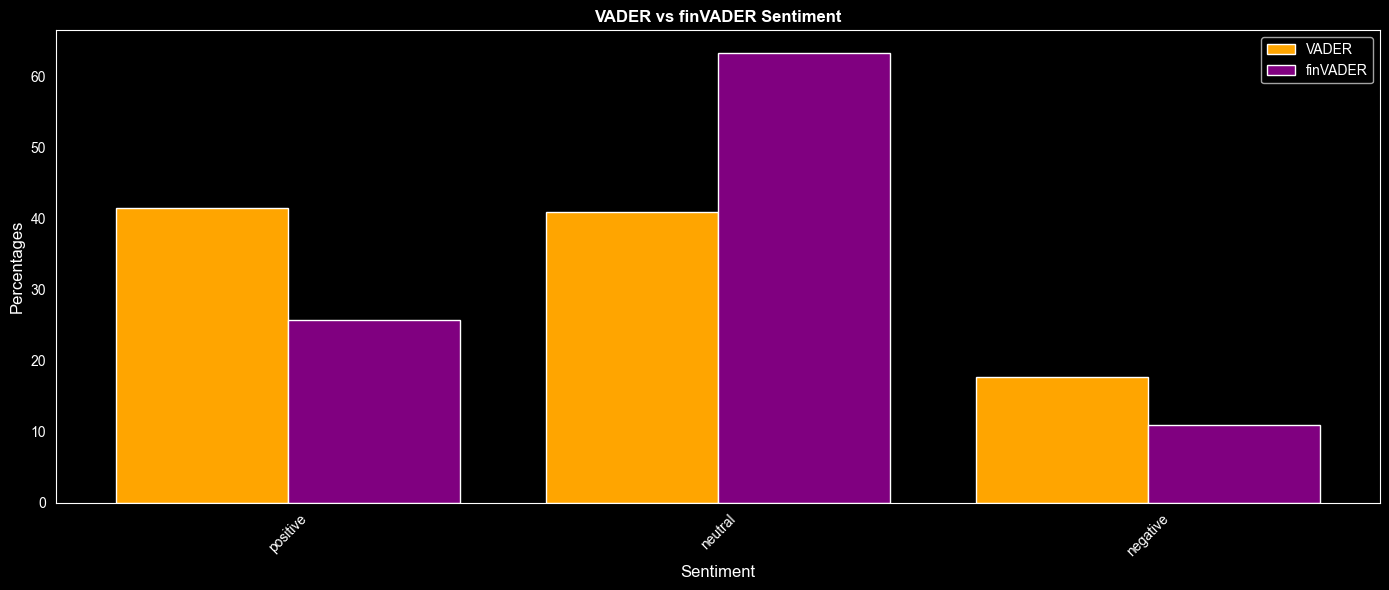

In [ ]:
# VADER vs finVADER Sentiment Stack Up
# NOTE TO SELF - Update this block with all three VADER, finVADER, finBERT and move to after the finBERT code block
# Then add in the manual labeling (separate?)

sns.set_style("dark")
plt.style.use("dark_background")

sentiments = ['positive','neutral','negative']
x = np.arange(len(sentiments))

plt.figure(figsize=(14, 6))

vader_total = finished_dataset['vader_sentiment'].value_counts().sum()
finvader_total = finished_dataset['sentiment_finVADER'].value_counts().sum()

vaderValues = [(finished_dataset['vader_sentiment'].value_counts().get(s, 0) / vader_total) * 100 for s in sentiments]

finVaderValues = [(finished_dataset['sentiment_finVADER'].value_counts().get(s,0) / finvader_total) * 100 for s in sentiments]

vaderBars = plt.bar(x - 0.2, vaderValues, 0.4, label='VADER', color='orange')
finVaderBars = plt.bar(x + 0.2, finVaderValues, 0.4, label='finVADER', color='purple')

plt.title('VADER vs finVADER Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Percentages', fontsize=12)
plt.xticks(x, sentiments, rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Saving the data to a pickle file again
save_path = '/Users/c.a.charo/Desktop/DataScienceCapstone/finished_dataset_after_finVADER.pkl'

finished_dataset.to_pickle(save_path)

## finBERT Labeling


## Loading the model and tokenizer and setting up the GPU for use

In [ ]:
# Loading the model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

# Switching to use the GPU. Originally missed this step and was running on CPU only and would have taken days
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = model.to(device)

0     made aapl check learn howtotrade exe watt imrs...
1     insanity today weirdo massive selling aapl bid...
2     stock performance low sbux tgt dvn ibm amzn ap...
3       tsla volkswagen push record recall tally higher
4     swing trading return day swingtrading forecast...
5     swing trading return day swingtrading forecast...
6     swing trading return day swingtrading forecast...
7     swing trading return day swingtrading forecast...
8     swing trading return day swingtrading forecast...
9     swing trading return day swingtrading forecast...
10    swing trading return day swingtrading forecast...
11    swing trading return day swingtrading forecast...
12    swing trading return day swingtrading forecast...
13    swing trading return day swingtrading forecast...
14    swing trading return day swingtrading forecast...
15    swing trading return day swingtrading forecast...
16    swing trading return day swingtrading forecast...
17    swing trading return day swingtrading fore

In [ ]:
print(finished_dataset['body'].head(20))

100%|██████████| 1059/1059 [53:47<00:00,  3.05s/it]


finbert_sentiment
neutral     3786004
negative     287249
positive     263192
Name: count, dtype: int64


In [ ]:
# Seeing that the finBERT worked on my sample but noting the extremely long time (30mins for 50k rows)
# I processed this on Google COLAB using GPU and batching

from tqdm import tqdm

sentiments = []
batch_size = 4096

for i in tqdm(range(0, len(finished_dataset), batch_size)):
  texts = finished_dataset.iloc[i:i+batch_size]['body'].tolist()



  # Tokenize the text - necessary because this tokenizer uses word pieces
  # previous tokenization used whole words (finBERT uses word pieces)
  inputs = tokenizer(texts,
                     add_special_tokens=True,
                     max_length=512,
                     truncation=True,
                     padding=True,  # makes each batch the same length
                     return_attention_mask=True,
                     return_tensors='pt').to(device) # this is inconjunction with the earlier code switching to gpu

  with torch.no_grad():        # Context Manager
    outputs = model(**inputs)
    # This gets the sentiment predictions
    sentiment = torch.nn.functional.softmax(outputs.logits, dim=1)
    sentiment_labels = sentiment.argmax(dim=1).cpu().numpy()

    label_map = {0: 'positive', 1: 'negative', 2: 'neutral'}
    batch_sentiments = [label_map[label] for label in sentiment_labels]
    sentiments.extend(batch_sentiments)

# Add back into the dataset

finished_dataset['finbert_sentiment'] = sentiments

print(finished_dataset['finbert_sentiment'].value_counts())

In [ ]:
# Saving the data to a pickle file again
Users/c.a.charo/Deskto
finished_dataset.to_pickle('finished_dataset_after_Fully_Labeled.pkl')

NameError: name 'pd' is not defined

In [ ]:
# Loading the data back in

finished_dataset = pd.read_pickle('finished_dataset_after_Fully_Labeled.pkl')

print(finished_dataset.head())
print(finished_dataset.shape)


             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  41304780      112.82      113.13     110.21   
1  2015-01-01       110.38  41304780      112.82      113.13     110.21   
2  2015-01-01    

## Final Label Comparison (VADER, finVADER, finBERT)

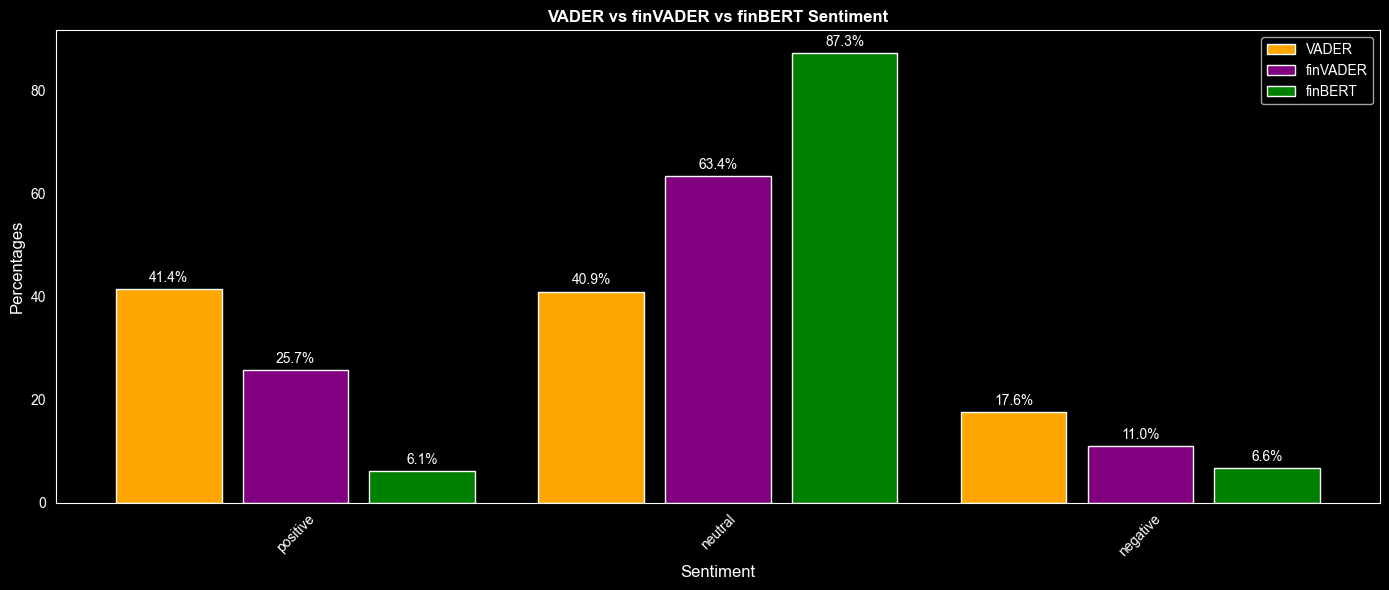

In [ ]:
# VADER vs finVADER Sentiment Stack Up
# NOTE TO SELF - Update this block with all three VADER, finVADER, finBERT and move to after the finBERT code block
# Then add in the manual labeling (separate?)

sns.set_style("dark")
plt.style.use("dark_background")

sentiments = ['positive','neutral','negative']
x = np.arange(len(sentiments))

plt.figure(figsize=(14, 6))

vader_total = finished_dataset['vader_sentiment'].value_counts().sum()
finvader_total = finished_dataset['sentiment_finVADER'].value_counts().sum()
finbert_total = finished_dataset['finbert_sentiment'].value_counts().sum()

vaderValues = [(finished_dataset['vader_sentiment'].value_counts().get(s, 0) / vader_total) * 100 for s in sentiments]

finVaderValues = [(finished_dataset['sentiment_finVADER'].value_counts().get(s,0) / finvader_total) * 100 for s in sentiments]

finBertValues = [(finished_dataset['finbert_sentiment'].value_counts().get(s,0) / finbert_total) * 100 for s in sentiments]

vaderBars = plt.bar(x - 0.3, vaderValues, 0.25, label='VADER', color='orange')
finVaderBars = plt.bar(x, finVaderValues, 0.25, label='finVADER', color='purple')
finBertBars = plt.bar(x + 0.3, finBertValues, 0.25, label='finBERT', color='green')

# Adding in the percentages to compare to our hand labeled data
plt.bar_label(vaderBars, fmt='%.1f%%', padding=3    )
plt.bar_label(finVaderBars, fmt='%.1f%%', padding=3    )
plt.bar_label(finBertBars, fmt='%.1f%%', padding=3    )

plt.title('VADER vs finVADER vs finBERT Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Percentages', fontsize=12)
plt.xticks(x, sentiments, rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# 7. Preparing the Dataset for Stock Price Predictions using SVM

Although the data has already been preprocessed, we need to prepare some items for the predictions portion of this work.

We have labels for the tweets, and we have stock price information but we need to:

1. Aggregate the tweets for a given day and stock
2. Calculate the price change

In [ ]:
# # Loading the data back in

finished_dataset = pd.read_pickle('finished_dataset_after_Fully_Labeled.pkl')

print(finished_dataset.head())

             tweet_id           post_date  \
0  550441509175443456 2015-01-01 00:00:57   
1  550441672312512512 2015-01-01 00:01:36   
2  550441732014223360 2015-01-01 00:01:50   
3  550442977802207232 2015-01-01 00:06:47   
4  550443807834402816 2015-01-01 00:10:05   

                                                body ticker_symbol       date  \
0  made aapl check learn howtotrade exe watt imrs...          AAPL 2015-01-01   
1  insanity today weirdo massive selling aapl bid...          AAPL 2015-01-01   
2  stock performance low sbux tgt dvn ibm amzn ap...          AMZN 2015-01-01   
3    tsla volkswagen push record recall tally higher          TSLA 2015-01-01   
4  swing trading return day swingtrading forecast...          AAPL 2015-01-01   

     day_date  close_value    volume  open_value  high_value  low_value  \
0  2015-01-01       110.38  41304780      112.82      113.13     110.21   
1  2015-01-01       110.38  41304780      112.82      113.13     110.21   
2  2015-01-01    

## Grouping the data by ticker and date

In [ ]:
# Built in label selector for easier switching. Just uncomment the label set you need

# label_method = 'finbert_sentiment'
# label_method = 'sentiment_finVADER'
label_method = 'vader_sentiment'

daily_sentiment = finished_dataset.groupby(['ticker_symbol', 'date']).agg({
    'tweet_id': 'count',
    label_method: [
        ('pct_positive', lambda x: (x == 'positive').sum() / len(x)),
        ('pct_negative', lambda x: (x == 'negative').sum() / len(x))
    ]}).reset_index()

daily_sentiment.columns = ['ticker_symbol', 'date', 'tweet_count', 'pct_positive', 'pct_negative']

# Printing out the sentiment aggregations
print(f"Daily aggregated Sentiment: {daily_sentiment.shape}")
print(daily_sentiment.head())

Daily aggregated Sentiment: (10948, 5)
  ticker_symbol       date  tweet_count  pct_positive  pct_negative
0          AAPL 2015-01-01          299      0.404682      0.143813
1          AAPL 2015-01-02          867      0.352941      0.183391
2          AAPL 2015-01-03          346      0.520231      0.104046
3          AAPL 2015-01-04          406      0.504926      0.108374
4          AAPL 2015-01-05         1147      0.410636      0.174368


In [ ]:
# Working with the stock prices to get the changes in value

# First things first, every row in our dataset has the closing stock price and we just need it once for each day so dropping the duplicates here
prices = finished_dataset[['ticker_symbol', 'date', 'close_value']].drop_duplicates()

# Merging the closing price data above with the daily_sentiment data from before
data = daily_sentiment.merge(prices, on=['ticker_symbol', 'date'], how='inner')
data = data.sort_values(['ticker_symbol', 'date']).reset_index(drop=True)

# Printing out the head to check my work
print(data.head())

  ticker_symbol       date  tweet_count  pct_positive  pct_negative  \
0          AAPL 2015-01-01          299      0.404682      0.143813   
1          AAPL 2015-01-02          867      0.352941      0.183391   
2          AAPL 2015-01-03          346      0.520231      0.104046   
3          AAPL 2015-01-04          406      0.504926      0.108374   
4          AAPL 2015-01-05         1147      0.410636      0.174368   

   close_value  
0       110.38  
1       109.33  
2       109.33  
3       109.33  
4       106.25  


In [ ]:
# We need the price movement calculated for each day as well

data['next_day_close'] = data.groupby('ticker_symbol')['close_value'].shift(-1)
data['next_day_up'] = (data['next_day_close'] >
data['close_value']).astype(int)
data = data.dropna(subset=['next_day_close'])

print(f"With next-day targets: {data.shape}")
print(f"Up days: {data['next_day_up'].sum()}, Down days: {(1-data['next_day_up']).sum()}")
print(data.head())

With next-day targets: (10942, 8)
Up days: 3994, Down days: 6948
  ticker_symbol       date  tweet_count  pct_positive  pct_negative  \
0          AAPL 2015-01-01          299      0.404682      0.143813   
1          AAPL 2015-01-02          867      0.352941      0.183391   
2          AAPL 2015-01-03          346      0.520231      0.104046   
3          AAPL 2015-01-04          406      0.504926      0.108374   
4          AAPL 2015-01-05         1147      0.410636      0.174368   

   close_value  next_day_close  next_day_up  
0       110.38          109.33            0  
1       109.33          109.33            0  
2       109.33          109.33            0  
3       109.33          106.25            0  
4       106.25          106.26            1  


In [ ]:
# Setting up thefeatures and target for training
X = data[['pct_positive', 'pct_negative', 'tweet_count']].values
y = data['next_day_up'].values

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

# Scaling the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Training the SVC using Particle Swarm Optimization for C and Gamma
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
!pip install pyswarm
from pyswarm import pso

def objective(params):
    C = params[0]
    gamma = params[1]

    svm = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced')
    scores = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring='f1_macro')

    return -scores.mean()

best_params, _ = pso(objective,
lb=[0.01, 0.0001],
ub=[100, 1.0],
swarmsize=15,
maxiter=20)

best_C = best_params[0]
best_gamma = best_params[1]

print(f"Best C: {best_C:.4f}")
print(f"Best gamma: {best_gamma:.4f}")


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Stopping search: maximum iterations reached --> 20
Best C: 40.0061
Best gamma: 0.0124


In [ ]:
# K Fold Validation with the best parameters found

from sklearn.model_selection import StratifiedKFold, cross_validate

svm =SVC(kernel='rbf', C=best_C, gamma=best_gamma, class_weight='balanced')

num_k_folds = 5
cv = StratifiedKFold(n_splits=num_k_folds, shuffle=True, random_state=25)

f1_macro_score = cross_val_score(svm, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
precision_score = cross_val_score(svm, X_train_scaled, y_train, cv=cv, scoring='precision')
recall_score = cross_val_score(svm, X_train_scaled, y_train, cv=cv, scoring='recall')
accuracy_score = cross_val_score(svm, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f"Mean f1_macro: {f1_macro_score.mean()*100: .2f}%")
print(f"Mean precision: {precision_score.mean()*100: .2f}%")
print(f"Mean recall: {recall_score.mean()*100: .2f}%")
print(f"Mean accuracy: {accuracy_score.mean()*100: .2f}%")

Mean f1_macro:  52.41%
Mean precision:  39.58%
Mean recall:  40.83%
Mean accuracy:  55.57%


In [ ]:
# Evaluating the Best/Final Model on

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
final_model = SVC(kernel='rbf', C=best_C, gamma=best_gamma, class_weight='balanced')
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Final Model Results")
print(f"Accuracy: {accuracy*100:.2f}%)")
print(f"F1 Macro: {f1_macro_score.mean()*100:.2f}%)")
print(f"Precision: {precision_score.mean()*100:.2f}%)")
print(f"Recall: {recall_score.mean()*100:.2f}%)")


print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Final Model Results
Accuracy: 55.64%)
F1 Macro: 52.41%)
Precision: 39.58%)
Recall: 40.83%)
Confusion Matrix
[[891 505]
 [466 327]]


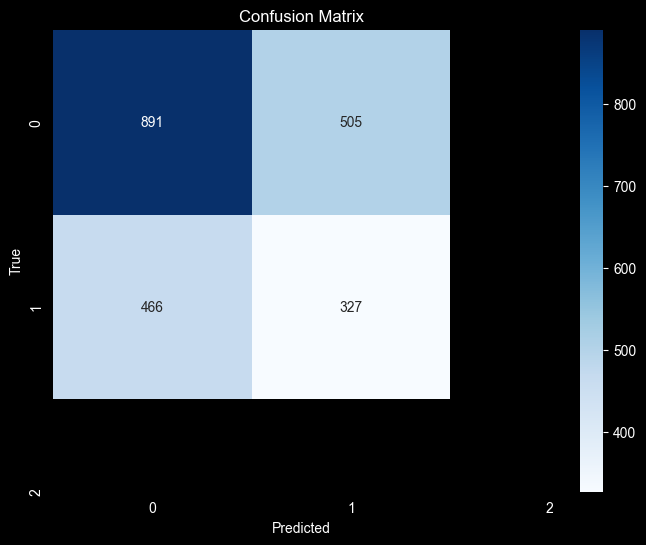

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

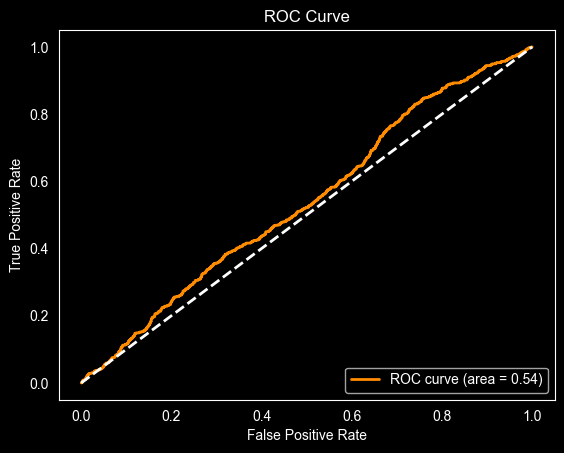

In [ ]:
# Add in the ROC curve and AUC score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = final_model.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='white', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()